# https://scib-metrics.readthedocs.io/en/latest/notebooks/lung_example.html

In [1]:
import sys
print(sys.version)
print(sys.executable)
import importlib
print(importlib.util.find_spec("scbiot"))
import scbiot as scb


3.12.8 (main, Jan 14 2025, 22:49:14) [Clang 19.1.6 ]
/home/figo/software/python_libs/scbiot/.venv/bin/python
ModuleSpec(name='scbiot', loader=<_frozen_importlib_external.SourceFileLoader object at 0x7750783bbd10>, origin='/home/figo/software/python_libs/scbiot/src/scbiot/__init__.py', submodule_search_locations=['/home/figo/software/python_libs/scbiot/src/scbiot'])
scbiot version 1.1.5


In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
# %pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu124
import torch
import os
import pandas as pd
import scbiot as scb
from scbiot.utils import set_seed

import harmonypy as hm
from umap import UMAP
# %pip install scib-metrics
from scib_metrics.benchmark import Benchmarker, BioConservation, BatchCorrection

set_seed(42)

from pathlib import Path
dir = Path.cwd()
print(dir)
parent_dir = dir.parent
print(parent_dir)


Random seed set as 42
/home/figo/software/python_libs/scbiot/examples
/home/figo/software/python_libs/scbiot


In [3]:
adata_path = f"{dir}/inputs/lung_atlas.h5ad"

adata = sc.read(
    adata_path,
    backup_url="https://figshare.com/ndownloader/files/24539942",
)
adata

AnnData object with n_obs × n_vars = 32472 × 15148
    obs: 'dataset', 'location', 'nGene', 'nUMI', 'patientGroup', 'percent.mito', 'protocol', 'sanger_type', 'size_factors', 'sampling_method', 'batch', 'cell_type', 'donor'
    layers: 'counts'

In [4]:
# ==== Make semi-supervised labels from true labels ====
# deps: numpy, pandas (AnnData in memory as `adata`)
import numpy as np
import pandas as pd

def make_semi_labels(
    adata,
    label_key="cell_type",
    out_key="semi_cell_type",
    unlabeled_tag="Unknown",
    frac_unlabeled=0.8,     # fraction to hide per class
    min_keep=20,            # keep at least this many labeled per class
    batch_key=None,         # e.g., "batch"; set None to ignore batch
    seed=42,
    protect_classes=None,   # list of classes to never mask
):
    """
    Create `out_key` by masking a fraction of cells to `unlabeled_tag`.
    - Works per class (or per (batch,class) if batch_key is given).
    - Ensures at least `min_keep` labeled remain per class group.
    """
    rng = np.random.default_rng(seed)

    # base labels as string; fill NAs with unlabeled_tag
    true_lab = adata.obs[label_key].astype("string").fillna(unlabeled_tag)

    # prepare output (start as a copy of true labels)
    semi = true_lab.copy()

    # ensure category list preserves originals + unlabeled_tag
    cats = list(pd.Categorical(adata.obs[label_key]).categories) \
           if pd.api.types.is_categorical_dtype(adata.obs[label_key]) \
           else sorted(pd.unique(true_lab))
    if unlabeled_tag not in cats:
        cats.append(unlabeled_tag)

    protect = set(protect_classes or [])

    def _mask_group(idx):
        # idx: numpy array of row indices for this (batch,class) group
        n = len(idx)
        if n == 0:
            return
        # how many to keep labeled
        keep_n = max(min_keep, int(round((1.0 - frac_unlabeled) * n)))
        keep_n = min(keep_n, n)
        # choose which to keep; mask the rest
        if keep_n < n:
            keep_idx = rng.choice(idx, size=keep_n, replace=False)
            mask_idx = np.setdiff1d(idx, keep_idx, assume_unique=False)
            semi.iloc[mask_idx] = unlabeled_tag

    if batch_key is None:
        # per-class masking
        for cls, idx in adata.obs.groupby(label_key).indices.items():
            if cls in protect or cls == unlabeled_tag:
                continue
            _mask_group(np.fromiter(idx, dtype=int))
    else:
        # stratify by (batch, class)
        for (b, cls), idx in adata.obs.groupby([batch_key, label_key]).indices.items():
            if cls in protect or cls == unlabeled_tag:
                continue
            _mask_group(np.fromiter(idx, dtype=int))

    # assign as categorical
    adata.obs[out_key] = pd.Categorical(semi, categories=cats)

    # quick summary
    before = pd.Series(true_lab).value_counts().sort_index()
    after  = pd.Series(adata.obs[out_key].astype(str)).value_counts().sort_index()
    print("\n=== Per-class counts (before -> after, including 'Unknown') ===")
    print(pd.DataFrame({"before": before, "after": after}).fillna(0).astype(int))

# ---------- usage ----------
# simplest (mask ~80% per class, keep ≥20 labeled each):
make_semi_labels(adata, label_key="cell_type", out_key="semi_cell_type")

# examples:
# - Stratify by batch: make_semi_labels(adata, batch_key="batch")
# - Keep small classes intact: make_semi_labels(adata, protect_classes=["rare_type"])
# - Be gentler (only hide 50%): make_semi_labels(adata, frac_unlabeled=0.5)
# - For tiny datasets, lower min_keep: make_semi_labels(adata, min_keep=5)



=== Per-class counts (before -> after, including 'Unknown') ===
                      before  after
B cell                  1353    271
Basal 1                 1972    394
Basal 2                 3072    614
Ciliated                3155    631
Dendritic cell          1367    273
Endothelium              988    198
Fibroblast               733    147
Ionocytes                 46     20
Lymphatic                341     68
Macrophage              7492   1498
Mast cell                889    178
Neutrophil_CD14_high    1626    325
Neutrophils_IL1R2        472     94
Secretory               2459    492
T/NK cell               1797    359
Type 1                   424     85
Type 2                  4286    857
Unknown                    0  25968


In [5]:
sc.pp.normalize_per_cell(adata, counts_per_cell_after=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=2000, flavor="cell_ranger", batch_key='batch')
sc.pp.scale(adata)
sc.tl.pca(adata, n_comps=50, use_highly_variable=True)

# sc.pp.highly_variable_genes(adata, n_top_genes=2000, flavor="seurat_v3", batch_key='batch')
# sc.pp.normalize_total(adata)
# sc.pp.log1p(adata)
# sc.pp.scale(adata)
# sc.tl.pca(adata, n_comps=50, use_highly_variable=True)

In [6]:
adata, metrics = scb.ot.integrate(
    adata,    
    modality='supervised',
    obsm_key="X_pca",
    batch_key="batch",
    out_key="X_supbiot",     
    label_key="semi_cell_type",
    unlabeled_category='Unknown'    
)
print(metrics)

adata = scb.ot.supbiot(
adata,
label_key="semi_cell_type",
unlabeled_category="Unknown",
pred_label_key='pred_cell_type',
pred_conf_key="pred_confidence",
min_conf=0.
)

[prealign] CORAL enabled target=auto strength=0.1
[baseline] KNN backend=FAISS-GPU mix=0.6434 strain=0.00000
[iter 01] mix=0.688 overlap0=0.829 strain=0.00399 floor~0.600 J=0.129 best_it=1
[iter 02] mix=0.738 overlap0=0.714 strain=0.01184 floor~0.607 J=0.174 best_it=2
[iter 03] mix=0.777 overlap0=0.652 strain=0.02146 floor~0.614 J=0.215 best_it=3
[iter 04] mix=0.803 overlap0=0.607 strain=0.03071 floor~0.621 J=0.230 best_it=4
[iter 05] mix=0.827 overlap0=0.568 strain=0.03953 floor~0.629 J=0.234 best_it=5
[iter 06] mix=0.846 overlap0=0.539 strain=0.04806 floor~0.636 J=0.236 best_it=6
[iter 07] mix=0.861 overlap0=0.521 strain=0.05627 floor~0.643 J=0.235 best_it=6
[iter 08] mix=0.860 overlap0=0.528 strain=0.05645 floor~0.650 J=0.238 best_it=8
[iter 09] mix=0.875 overlap0=0.504 strain=0.06443 floor~0.657 J=0.222 best_it=8
[iter 10] mix=0.875 overlap0=0.505 strain=0.06467 floor~0.664 J=0.219 best_it=8
[iter 11] mix=0.875 overlap0=0.506 strain=0.06487 floor~0.671 J=0.217 best_it=8
[early stop

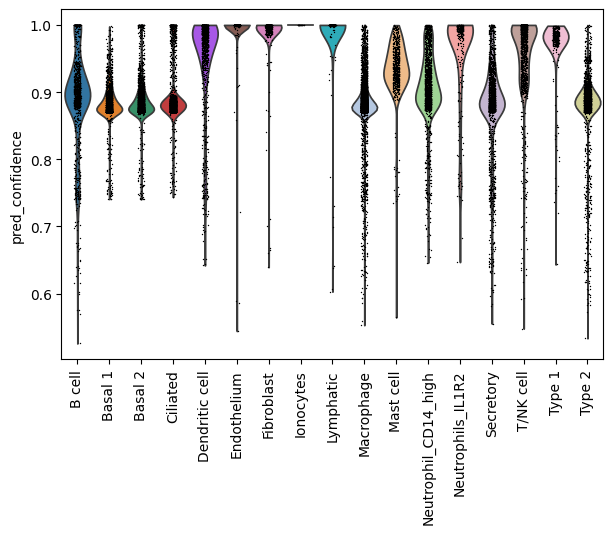

In [7]:
ax = sc.pl.violin(adata, keys="pred_confidence", groupby="pred_cell_type", rotation=90, show=False)
ax.get_legend().remove()
plt.tight_layout()
plt.show()

In [8]:
print(adata.obs["pred_cell_type"].isna().sum())
# combine labels and unlabels
adata.obs["pred_cell_type"] = (
    adata.obs["pred_cell_type"].astype("string")
    .fillna(adata.obs["semi_cell_type"].astype("string"))
)

print(adata.obs["pred_cell_type"].isna().sum())

6504
0


In [9]:
scb.pp.setup_anndata(adata, var_key='X_supbiot', batch_key='batch', pseudo_key='pred_cell_type', true_key=None)

{'var_key': 'X_supbiot',
 'batch_key': 'batch',
 'pseudo_key': 'pred_cell_type',
 'true_key': None}

In [10]:
model = scb.models.vae(adata, verbose=True)

Random seed set as 42
[Explicit labels] has_pseudo=True
[Explicit labels] batch_train/test: torch.Size([29224]) / torch.Size([3248])
[Explicit labels] pseudo_train/test: torch.Size([29224]) / torch.Size([3248])


In [11]:
model.train()

Training:   1%|▏         | 1/80 [00:03<04:30,  3.42s/it, epoch=1/80, Train_loss=1.9685, Test_loss=1.7758]

Saved whole dataset latents (N=32472)
{'Train NMI': 0.288, 'Train ARI': 0.182, 'Train ACC': 0.379, 'Train kBET': 0.897, 'Train CCR': 0.022}


Training:   2%|▎         | 2/80 [00:04<02:55,  2.25s/it, epoch=2/80, Train_loss=2.6999, Test_loss=2.3900]

Saved whole dataset latents (N=32472)
{'Train NMI': 0.368, 'Train ARI': 0.24, 'Train ACC': 0.428, 'Train kBET': 0.871, 'Train CCR': 0.0}


Training:   4%|▍         | 3/80 [00:06<02:33,  1.99s/it, epoch=3/80, Train_loss=3.0043, Test_loss=2.7830]

...

{'Train NMI': 0.848, 'Train ARI': 0.754, 'Train ACC': 0.81, 'Train kBET': 0.225, 'Train CCR': 99.484}


Training: 100%|██████████| 80/80 [01:39<00:00,  1.13s/it, epoch=80/80, Train_loss=1.8555, Test_loss=1.8902]

{'Train NMI': 0.844, 'Train ARI': 0.731, 'Train ACC': 0.772, 'Train kBET': 0.221, 'Train CCR': 97.526}


Training: 81it [01:40,  1.25s/it, epoch=81/80, Train_loss=1.8548, Test_loss=1.8860]                        

{'Train NMI': 0.843, 'Train ARI': 0.726, 'Train ACC': 0.765, 'Train kBET': 0.225, 'Train CCR': 98.86}
Training time: 1.68 mins


In [12]:
SCBIOT_LATENT_KEY = "supBIOT"
adata.obsm[SCBIOT_LATENT_KEY] = model.get_latent_representation(n_components=50, svd_solver='arpack', random_state=42)

In [13]:
methods = ["X_supbiot", "supBIOT"] # , "scBIOT_OT"
leiden_methods = [f'{method}_leiden' for method in methods]

for method, leiden_method in zip(methods, leiden_methods):
    sc.pp.neighbors(adata, use_rep=method)
    sc.tl.umap(adata)
    adata.obsm[f"X_umap_{method}"] = adata.obsm["X_umap"].copy()
    sc.tl.leiden(adata, key_added=leiden_method, resolution=0.8)

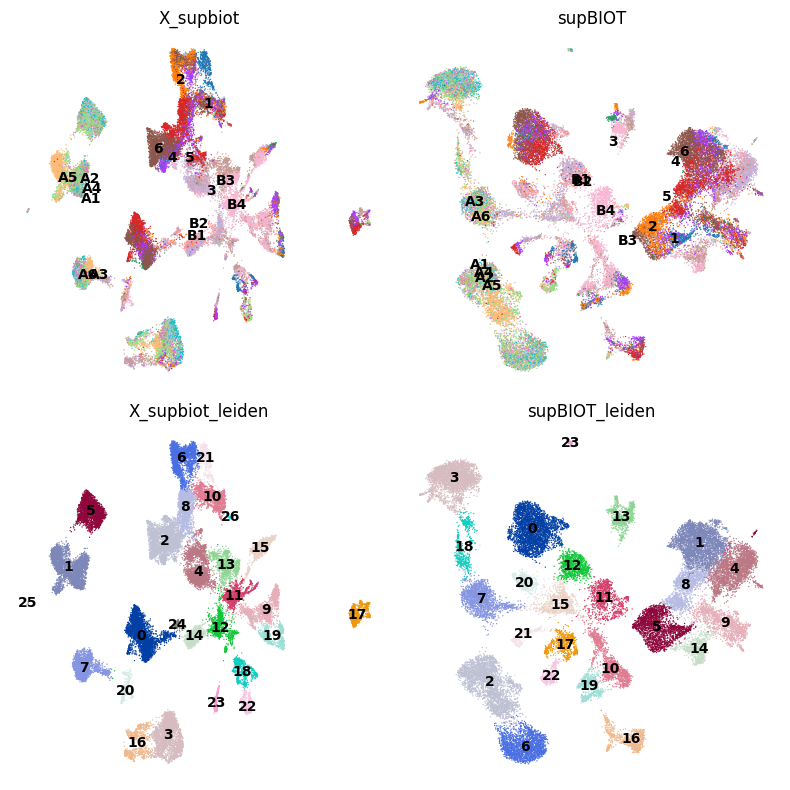

In [14]:
import matplotlib.pyplot as plt
import scanpy as sc


# 2 rows x len(methods) columns
fig, axes = plt.subplots(
    2,
    len(methods),
    figsize=(4 * len(methods), 8),
    squeeze=False  # ensures axes is a 2D array
)

for col, method in enumerate(methods):
    # 1) Top row (row=0): color by "batch"
    sc.pl.embedding(
        adata,
        basis=f"X_umap_{method}",  # The coordinates stored in adata.obsm["X_umap_{method}"]
        color="batch",            # Assume adata.obs["batch"] exists
        frameon=False,
        ax=axes[0, col],
        show=False,
        legend_loc="on data",
        legend_fontsize=10,  # smaller font
        title=f"{method}"
    )

    # 2) Bottom row (row=1): color by the Leiden clusters for this method
    leiden_key = f"{method}_leiden"
    sc.pl.embedding(
        adata,
        basis=f"X_umap_{method}",
        color=leiden_key,         # Column in adata.obs
        frameon=False,
        ax=axes[1, col],
        show=False,
        legend_loc="on data",
        legend_fontsize=10,  # smaller font
        # title=f"{method}"
    )

plt.tight_layout()
# fig.savefig("batch_and_leiden_per_embedding.pdf", dpi=300)
# plt.close(fig)


In [15]:
adata

AnnData object with n_obs × n_vars = 32472 × 15148
    obs: 'dataset', 'location', 'nGene', 'nUMI', 'patientGroup', 'percent.mito', 'protocol', 'sanger_type', 'size_factors', 'sampling_method', 'batch', 'cell_type', 'donor', 'semi_cell_type', 'n_counts', 'pred_cell_type', 'pred_confidence', 'X_supbiot_leiden', 'supBIOT_leiden'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mean', 'std'
    uns: 'log1p', 'hvg', 'pca', '_ot_alignment', '_supbiot', 'pred_cell_type_colors', '_scbiot_setup', 'neighbors', 'umap', 'X_supbiot_leiden', 'supBIOT_leiden', 'batch_colors', 'X_supbiot_leiden_colors', 'supBIOT_leiden_colors'
    obsm: 'X_pca', 'X_supbiot', 'supBIOT', 'X_umap', 'X_umap_X_supbiot', 'X_umap_supBIOT'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

In [16]:
# fix the bug in the scib-metrics
# change _graph_connectivity.py: <mask = labels == label> to <mask = (labels == label).to_numpy()> 

In [17]:
bm = Benchmarker(
    adata, 
    batch_key="batch",
    label_key="cell_type",
    bio_conservation_metrics=BioConservation(),
    batch_correction_metrics=BatchCorrection(),    
    embedding_obsm_keys=["X_pca", "X_supbiot", "supBIOT"], # , "scANVI"
    n_jobs=-1
    
)
bm.benchmark()

Embeddings: 100%|██████████| 3/3 [00:59<00:00, 19.70s/it]


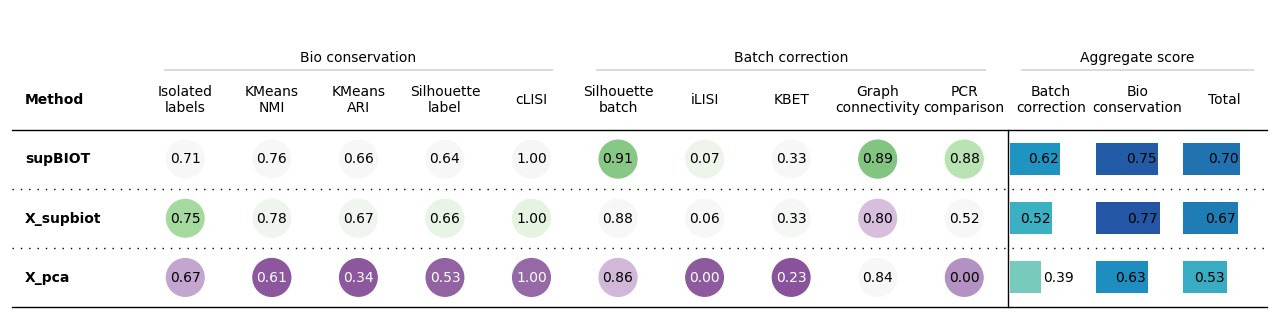

In [18]:
bm.plot_results_table(min_max_scale=False)